# Лабораторная работа №5

**Тема:** ансамбли моделей машинного обучения. Часть 1.

**Цель работы:** изучить ансамбли моделей машинного обучения и сравнить качество нескольких ансамблевых алгоритмов на одной задаче.

**Датасеты:** `lr3/pokemon_complete.csv`, `lr3/pokemon_types.csv`.


## Описание задания

В работе решается задача регрессии: необходимо спрогнозировать базовый опыт Pokémon `base_experience` по его характеристикам, физическим параметрам, редкости, поколению, типам и признакам взаимодействия типов.

Для сравнения выбраны четыре ансамблевые модели:

- `RandomForestRegressor` — случайный лес, модель группы бэггинга;
- `ExtraTreesRegressor` — сверхслучайные деревья, модель группы бэггинга;
- `AdaBoostRegressor`;
- `GradientBoostingRegressor`.

Качество моделей оценивается по метрике `MAE`. Чем меньше значение `MAE`, тем точнее модель предсказывает базовый опыт Pokémon.


## Импорт библиотек


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import (
    AdaBoostRegressor,
    ExtraTreesRegressor,
    GradientBoostingRegressor,
    RandomForestRegressor,
)
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

%matplotlib inline
plt.style.use('default')
RANDOM_STATE = 42


## Загрузка данных


In [2]:
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'lr3' / 'pokemon_complete.csv').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

pokemon_df = pd.read_csv(PROJECT_ROOT / 'lr3' / 'pokemon_complete.csv')
types_df = pd.read_csv(PROJECT_ROOT / 'lr3' / 'pokemon_types.csv')

print('Размер основной таблицы:', pokemon_df.shape)
print('Размер таблицы типов:', types_df.shape)
display(pokemon_df.head())
display(types_df.head())


Размер основной таблицы: (1350, 31)
Размер таблицы типов: (18, 7)


,pokedex_number,name,type_1,type_2,hp,attack,defense,sp_attack,sp_defense,speed,...,shape,egg_groups,habitat,growth_rate,capture_rate,base_happiness,genus,evolution_chain_id,flavor_text,sprite_url
0,1,Bulbasaur,Grass,Poison,45,49,49,65,65,45,...,quadruped,monster|plant,grassland,medium-slow,45,70,Seed Pokémon,1,A strange seed was planted on its back at birt...,https://raw.githubusercontent.com/PokeAPI/spri...
1,2,Ivysaur,Grass,Poison,60,62,63,80,80,60,...,quadruped,monster|plant,grassland,medium-slow,45,70,Seed Pokémon,1,"When the bulb on its back grows large, it appe...",https://raw.githubusercontent.com/PokeAPI/spri...
2,3,Venusaur,Grass,Poison,80,82,83,100,100,80,...,quadruped,monster|plant,grassland,medium-slow,45,70,Seed Pokémon,1,The plant blooms when it is absorbing solar en...,https://raw.githubusercontent.com/PokeAPI/spri...
3,4,Charmander,Fire,NaN,39,52,43,60,50,65,...,upright,monster|dragon,mountain,medium-slow,45,70,Lizard Pokémon,2,"Obviously prefers hot places. When it rains, s...",https://raw.githubusercontent.com/PokeAPI/spri...
4,5,Charmeleon,Fire,NaN,58,64,58,80,65,80,...,upright,monster|dragon,mountain,medium-slow,45,70,Flame Pokémon,2,"When it swings its burning tail, it elevates t...",https://raw.githubusercontent.com/PokeAPI/spri...


,type,double_damage_to,half_damage_to,no_damage_to,double_damage_from,half_damage_from,no_damage_from
0,normal,NaN,rock|steel,ghost,fighting,NaN,ghost
1,fighting,normal|rock|steel|ice|dark,flying|poison|bug|psychic|fairy,ghost,flying|psychic|fairy,rock|bug|dark,NaN
2,flying,fighting|bug|grass,rock|steel|electric,NaN,rock|electric|ice,fighting|bug|grass,ground
3,poison,grass|fairy,poison|ground|rock|ghost,steel,ground|psychic,fighting|poison|bug|grass|fairy,NaN
4,ground,poison|rock|steel|fire|electric,bug|grass,flying,water|grass|ice,poison|rock,electric


## Предобработка данных

В основной таблице есть пропуски в некоторых признаках и в целевом столбце `base_experience`. Строки без целевого значения удаляются, потому что по ним нельзя обучать модель. Остальные пропуски заполняются внутри пайплайна: числовые признаки медианой, категориальные признаки самым частым значением.

Таблица `pokemon_types.csv` используется для создания дополнительных числовых признаков: количества типов, которым Pokémon наносит двойной, половинный или нулевой урон, а также количества типов, от которых он получает повышенный, пониженный или нулевой урон.


In [3]:
missing_summary = pokemon_df.isna().sum().sort_values(ascending=False)
missing_summary[missing_summary > 0]


habitat            830
type_2             585
hidden_ability     362
sprite_url          60
base_experience     48
abilities           25
dtype: int64

In [4]:
def count_type_list(value):
    """Считает количество типов в строке вида 'fire|water'."""
    if pd.isna(value) or value == '':
        return 0
    return len(str(value).split('|'))

interaction_columns = [
    'double_damage_to',
    'half_damage_to',
    'no_damage_to',
    'double_damage_from',
    'half_damage_from',
    'no_damage_from',
]

type_features = types_df.copy()
type_features['type'] = type_features['type'].str.lower()

for column in interaction_columns:
    type_features[f'{column}_count'] = type_features[column].apply(count_type_list)

type_features = type_features[['type'] + [f'{column}_count' for column in interaction_columns]]
type_features.head()


,type,double_damage_to_count,half_damage_to_count,no_damage_to_count,double_damage_from_count,half_damage_from_count,no_damage_from_count
0,normal,0,2,1,1,0,1
1,fighting,5,5,1,3,3,0
2,flying,3,3,0,3,3,1
3,poison,2,4,1,2,5,0
4,ground,5,2,1,3,2,1


In [5]:
primary_type_features = type_features.add_prefix('type_1_').rename(columns={'type_1_type': 'type_1_key'})
secondary_type_features = type_features.add_prefix('type_2_').rename(columns={'type_2_type': 'type_2_key'})

data = pokemon_df.copy()
data['type_1_key'] = data['type_1'].str.lower()
data['type_2_key'] = data['type_2'].str.lower()

data = data.merge(primary_type_features, on='type_1_key', how='left')
data = data.merge(secondary_type_features, on='type_2_key', how='left')

type_count_columns = [column for column in data.columns if column.endswith('_count')]
data[type_count_columns] = data[type_count_columns].fillna(0)

data[type_count_columns].head()


,type_1_double_damage_to_count,type_1_half_damage_to_count,type_1_no_damage_to_count,type_1_double_damage_from_count,type_1_half_damage_from_count,type_1_no_damage_from_count,type_2_double_damage_to_count,type_2_half_damage_to_count,type_2_no_damage_to_count,type_2_double_damage_from_count,type_2_half_damage_from_count,type_2_no_damage_from_count
0,3,7,0,5,4,0,2.0,4.0,1.0,2.0,5.0,0.0
1,3,7,0,5,4,0,2.0,4.0,1.0,2.0,5.0,0.0
2,3,7,0,5,4,0,2.0,4.0,1.0,2.0,5.0,0.0
3,4,4,0,3,6,0,0.0,0.0,0.0,0.0,0.0,0.0
4,4,4,0,3,6,0,0.0,0.0,0.0,0.0,0.0,0.0


## Формирование обучающей и тестовой выборки


In [6]:
target = 'base_experience'

feature_columns = [
    'hp', 'attack', 'defense', 'sp_attack', 'sp_defense', 'speed',
    'base_stat_total', 'height_m', 'weight_kg', 'capture_rate', 'base_happiness',
    'generation', 'is_legendary', 'is_mythical', 'is_baby',
    'type_1', 'type_2', 'color', 'shape', 'habitat', 'growth_rate',
] + type_count_columns

model_df = data[feature_columns + [target]].dropna(subset=[target]).copy()

bool_columns = model_df.select_dtypes(include=['bool']).columns.tolist()
model_df[bool_columns] = model_df[bool_columns].astype(int)

X = model_df[feature_columns]
y = model_df[target]

categorical_features = X.select_dtypes(include=['object']).columns.tolist()
numeric_features = X.select_dtypes(exclude=['object']).columns.tolist()

print('Размер X:', X.shape)
print('Размер y:', y.shape)
print('Числовых признаков:', len(numeric_features))
print('Категориальных признаков:', len(categorical_features))


Размер X: (1302, 33)
Размер y: (1302,)
Числовых признаков: 26
Категориальных признаков: 7


C:\Users\Den\AppData\Local\Temp\ipykernel_11016\3222041618.py:18: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(include=['object']).columns.tolist()


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=RANDOM_STATE,
)

print('Обучающая выборка:', X_train.shape)
print('Тестовая выборка:', X_test.shape)


Обучающая выборка: (976, 33)
Тестовая выборка: (326, 33)


In [8]:
def make_one_hot_encoder():
    try:
        return OneHotEncoder(handle_unknown='ignore', sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown='ignore', sparse=False)

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', make_one_hot_encoder()),
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features),
])


## Обучение ансамблевых моделей


In [9]:
models = {
    'Random Forest': RandomForestRegressor(
        n_estimators=250,
        max_depth=8,
        min_samples_leaf=3,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
    'Extra Trees': ExtraTreesRegressor(
        n_estimators=250,
        max_depth=8,
        min_samples_leaf=3,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
    'AdaBoost': AdaBoostRegressor(
        n_estimators=150,
        learning_rate=0.05,
        random_state=RANDOM_STATE,
    ),
    'Gradient Boosting': GradientBoostingRegressor(
        n_estimators=150,
        learning_rate=0.05,
        max_depth=3,
        random_state=RANDOM_STATE,
    ),
}

trained_models = {}
rows = []

for model_name, model in models.items():
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', model),
    ])
    pipeline.fit(X_train, y_train)
    predictions = pipeline.predict(X_test)
    trained_models[model_name] = pipeline
    rows.append({
        'model': model_name,
        'MAE': mean_absolute_error(y_test, predictions),
    })

metrics_df = pd.DataFrame(rows).sort_values('MAE')
metrics_df


,model,MAE
0,Random Forest,13.209197
1,Extra Trees,13.637089
3,Gradient Boosting,15.449818
2,AdaBoost,22.314416


## Сравнение качества моделей


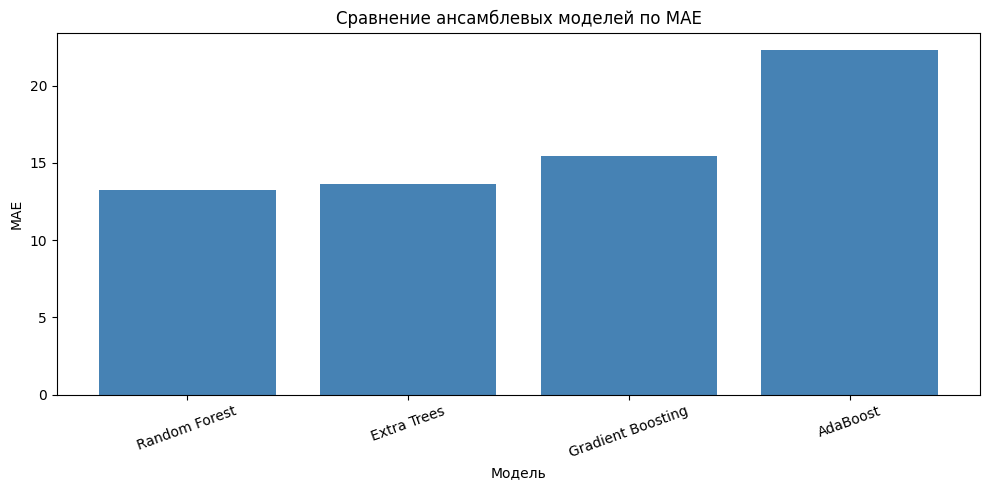

In [10]:
plt.figure(figsize=(10, 5))
plt.bar(metrics_df['model'], metrics_df['MAE'], color='steelblue')
plt.title('Сравнение ансамблевых моделей по MAE')
plt.xlabel('Модель')
plt.ylabel('MAE')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


In [11]:
best_model_name = metrics_df.iloc[0]['model']
print('Лучшая модель по MAE:', best_model_name)
metrics_df


Лучшая модель по MAE: Random Forest


,model,MAE
0,Random Forest,13.209197
1,Extra Trees,13.637089
3,Gradient Boosting,15.449818
2,AdaBoost,22.314416


## Важность признаков лучшей модели


In [12]:
best_pipeline = trained_models[best_model_name]
best_model = best_pipeline.named_steps['model']
preprocessor_fitted = best_pipeline.named_steps['preprocessor']

encoded_feature_names = preprocessor_fitted.get_feature_names_out()

if hasattr(best_model, 'feature_importances_'):
    feature_importance = pd.DataFrame({
        'feature': encoded_feature_names,
        'importance': best_model.feature_importances_,
    }).sort_values('importance', ascending=False)
else:
    feature_importance = pd.DataFrame(columns=['feature', 'importance'])

feature_importance.head(15)


,feature,importance
6,num__base_stat_total,0.911179
9,num__capture_rate,0.012555
10,num__base_happiness,0.009442
0,num__hp,0.006626
107,cat__growth_rate_medium-slow,0.006567
2,num__defense,0.005396
5,num__speed,0.004594
1,num__attack,0.004518
4,num__sp_defense,0.003826
104,cat__growth_rate_fast,0.003219


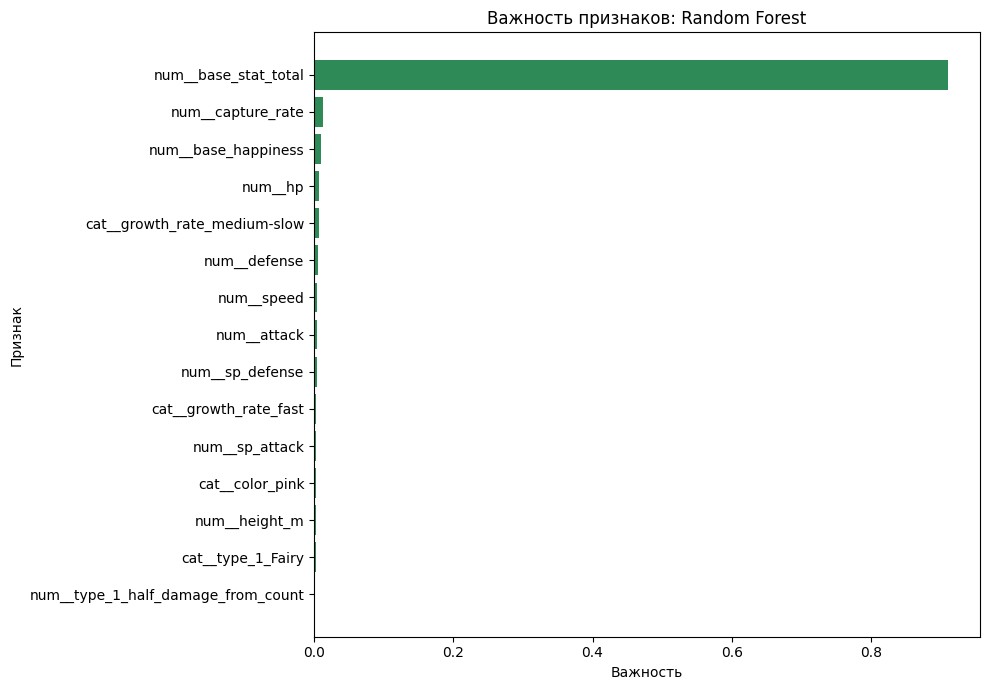

In [13]:
top_features = feature_importance.head(15).sort_values('importance')

plt.figure(figsize=(10, 7))
plt.barh(top_features['feature'], top_features['importance'], color='seagreen')
plt.title(f'Важность признаков: {best_model_name}')
plt.xlabel('Важность')
plt.ylabel('Признак')
plt.tight_layout()
plt.show()


## Вывод

В ходе лабораторной работы были подготовлены данные о Pokémon, выполнено заполнение пропусков и кодирование категориальных признаков. Выборка была разделена на обучающую и тестовую с помощью `train_test_split`.

Были обучены четыре ансамблевые модели: случайный лес, сверхслучайные деревья, AdaBoost и градиентный бустинг. По таблице и графику `MAE` можно определить модель с наименьшей средней абсолютной ошибкой. Дополнительно для лучшей модели построен график важности признаков, показывающий, какие характеристики сильнее всего влияют на прогноз `base_experience`.
